KM1 – FashionMNIST na własnej bibliotece AD

In [1]:
# Importy i znalezienie MiniAD.jl

miniad_path1 = joinpath(@__DIR__, "src", "MiniAD.jl")
miniad_path2 = joinpath(@__DIR__, "..", "src", "MiniAD.jl")

if isfile(miniad_path1)
    include(miniad_path1)
elseif isfile(miniad_path2)
    include(miniad_path2)
else
    error("Nie znaleziono src/MiniAD.jl")
end

using .MiniAD
using .MiniAD: DropoutOp
using Random
using Statistics

Random.seed!(0)

println("pwd = ", pwd())
println("@__DIR__ = ", @__DIR__)


pwd = /Users/kasia/PW/algorytmy/KM1
@__DIR__ = /Users/kasia/PW/algorytmy/KM1


In [2]:
# Dane

train_X, train_y, test_X, test_y = load_fashionmnist("data")

println("train_X size = ", size(train_X))
println("train_y size = ", size(train_y))
println("test_X size  = ", size(test_X))
println("test_y size  = ", size(test_y))


train_X size = (28, 28, 1, 60000)
train_y size = (10, 60000)
test_X size  = (28, 28, 1, 10000)
test_y size  = (10, 10000)


W naszym projekcie:
- obrazy mają rozmiar `28 x 28 x 1 x N`
- etykiety mają rozmiar `10 x N`

In [3]:
# Architektura modelu

model = Chain(
    Conv2D(1, 6, (3, 3), padding=1, bias=false),
    MaxPool2D((2, 2)),
    Conv2D(6, 16, (3, 3), padding=1, bias=false),
    MaxPool2D((2, 2)), # po dwóch maxpoolach rozmiar przestrzenny zmniejsza się z 28x28 do 7x7
    Flatten(),
    Dense(16 * 7 * 7, 84), #16 kanałów, 7x7 po dwóch maxpoolach, 84 neurony w warstwie ukrytej
    relu,
    Dropout(0.4),
    Dense(84, 10)  #10 klas w FashionMNIST
)

println(model)


Chain(Any[Conv2D(Variable{Array{Float32, 4}}(Float32[0.44452056 0.0584076 -0.110610954; 0.063131794 -0.5684065 -0.5125828; 0.71892434 0.14699203 0.21793534;;;; -0.037991945 0.1475762 0.8599942; -0.3829835 -0.22600561 -0.4988861; -0.971581 -0.44518927 0.13772789;;;; 0.5878001 -0.5708958 -0.46940792; -0.20236236 -0.27268818 -0.48240843; -0.011838178 0.036231034 -0.0597725;;;; -0.7055 0.4478695 0.047417592; 0.26299664 -0.0953756 -0.138664; -0.16805007 0.11200495 0.0947;;;; 0.36230743 -0.26866233 -0.83592016; -0.42765564 0.86212474 0.35062134; 0.2943851 0.37277648 0.043476347;;;; 0.36527163 -0.21646571 -0.92382276; 0.016412152 -0.25506023 -0.6604452; 0.20453505 0.10831887 0.20282777], Float32[0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0], :W), nothing, (1, 1), (1, 1)), MaxPool2D((2, 2), (2,

Excessive output truncated after 524297 bytes.

 0.0003394424 -0.12294601 0.0374105 0.032240987 -0.004470811 -0.019300302 0.032199 0.014152723 0.015046968 -0.01685602 0.051303115 -0.0009327916 -0.0055723777 0.03357416 0.06782131 0.012798765 0.014601211 0.005921977 0.06249866 0.048239484 0.05258757 -0.10363217 0.0013481306 0.031666264 0.1054646 0.06875044 0.010540035 0.010689378 0.08554753 0.053278416 0.096846424 0.023565697 0.021320183 0.04203892 -0.049757127 -0.022185432 -0.031614468 -0.1216177 -0.090588115 -0.058123153 0.05493743 -0.009491988 -0.043940816 -0.010515201 0.0065741926 -0.094834745 -0.026712481 0.041113675 0.050183848 -0.034844592 -0.016536416 0.072079696 -0.035981428 -0.0443304 0.016228033 0.025668807 -0.051072367 -0.016099429 -0.01888265 -0.05391046 0.021158656 0.015577528 -0.007004703 -0.0017650943 -0.057098854 0.049197197 0.07603906 0.020208685 -0.10071801 0.0032349234 0.034583014 0.050136246 -0.014474706 -0.019360818 -0.044090085 0.011599992 -0.06298785 0.057431705 -0.069007725 0.07672428 -0.0009042021 0.006163671

To odpowiada architekturze referencyjnej:
`Conv(1→6), MaxPool, Conv(6→16), MaxPool, Flatten, Dense(784→84), relu, Dropout(0.4), Dense(84→10)`

In [4]:
# Pierwsza szybka próba – forward dla małego batcha

x1 = train_X[:, :, :, 1:10]
y1 = train_y[:, 1:10]

x1_var = Variable(x1, name=:x1)
y1hat = model(x1_var)

order_probe = topo_sort(y1hat)
forward!(order_probe)

println("size(y1hat) = ", size(value(y1hat)))
println("pred vs true = ")
println(hcat(argmax_classes(value(y1hat)), argmax_classes(y1)))


In [5]:
# Helpery do grafu, treningu i ewaluacji

function build_graph(model, batch_size)
    x = Variable(zeros(Float32, 28, 28, 1, batch_size), name=:x)
    y = Variable(zeros(Float32, 10, batch_size), name=:y)
    logits = model(x)
    loss = logitcrossentropy(logits, y)
    order = topo_sort(loss)
    dropout_nodes = [node for node in order if node isa OperatorNode && node.f isa DropoutOp]
    return x, y, logits, loss, order, dropout_nodes
end

function reset_dropout_masks!(dropout_nodes)
    for node in dropout_nodes
        node.f.mask = nothing
    end
end

function loss_and_accuracy(model, X, Y, batch_size, x_var, y_var, logits, loss, order)
    total_loss = 0f0
    total_correct = 0
    total_samples = 0

    eval!(model)

    for (xb, yb) in eachbatch(X, Y, batch_size, shuffle=false)
        x_var.output = xb
        y_var.output = yb

        forward!(order)

        batch_logits = value(logits)
        batch_size_actual = size(xb, 4)

        total_loss += value(loss) * batch_size_actual
        total_correct += sum(argmax_classes(batch_logits) .== argmax_classes(yb))
        total_samples += batch_size_actual
    end

    return total_loss / total_samples, round(100 * total_correct / total_samples; digits=2)
end


loss_and_accuracy (generic function with 1 method)

In [6]:
# Hiperparametry

settings = (;
    eta = 0.01f0,
    epochs = 3,
    batchsize = 10,
)

ps = params(model)
eval_batchsize = size(test_X, 4)

println(settings)


In [7]:
# Budowa grafów treningowego i ewaluacyjnego

train!(model)
train_x_var, train_y_var, train_logits, train_loss, train_order, train_dropout_nodes =
    build_graph(model, settings.batchsize)

eval!(model)
eval_x_var, eval_y_var, eval_logits, eval_loss, eval_order, _ =
    build_graph(model, eval_batchsize)

println("Grafy gotowe.")


In [8]:
# Stan przed treningiem

initial_test_loss, initial_test_acc = loss_and_accuracy(
    model, test_X, test_y, eval_batchsize,
    eval_x_var, eval_y_var, eval_logits, eval_loss, eval_order
)

println("loss_and_accuracy(model, test) before training = ",
    (loss = initial_test_loss, acc = initial_test_acc))


Oczekiwany wynik przed treningiem: accuracy powinno być blisko losowego zgadywania, czyli około `10%`.

In [9]:
# Trening

train_log = NamedTuple[]
accuracy = zeros(Float64, settings.epochs, 2)
epoch_times = zeros(Float64, settings.epochs)

println("\n" * "="^80)
println("KM1 FashionMNIST Training Benchmark")
println("="^80)
println("Model: 2-layer CNN with Dropout")
println("Hyperparameters: batch_size=$(settings.batchsize), lr=$(settings.eta), epochs=$(settings.epochs)")
println("="^80)

start_time = time()

for epoch in 1:settings.epochs
    train!(model)

    epoch_start = time()

    for (x, y) in eachbatch(train_X, train_y, settings.batchsize, shuffle=true)
        train_x_var.output = x
        train_y_var.output = y

        reset_dropout_masks!(train_dropout_nodes)

        forward!(train_order)
        backward!(train_order)
        sgd_step!(ps, settings.eta)
    end

    epoch_times[epoch] = time() - epoch_start

    train_loss_epoch, train_acc_epoch = loss_and_accuracy(
        model, train_X, train_y, eval_batchsize,
        eval_x_var, eval_y_var, eval_logits, eval_loss, eval_order
    )

    test_loss_epoch, test_acc_epoch = loss_and_accuracy(
        model, test_X, test_y, eval_batchsize,
        eval_x_var, eval_y_var, eval_logits, eval_loss, eval_order
    )

    nt = (; epoch,
            train_loss = train_loss_epoch,
            train_acc = train_acc_epoch,
            test_loss = test_loss_epoch,
            test_acc = test_acc_epoch,
            epoch_time = epoch_times[epoch])

    push!(train_log, nt)
    accuracy[epoch, 1] = train_acc_epoch
    accuracy[epoch, 2] = test_acc_epoch

    println(
        "Epoch $(epoch)/$(settings.epochs) | " *
        "epoch_time=$(round(epoch_times[epoch], digits=2))s | " *
        "train_acc=$(train_acc_epoch)% | " *
        "test_loss=$(round(test_loss_epoch, digits=4)) | " *
        "test_acc=$(test_acc_epoch)%"
    )
end


In [10]:
# Wynik końcowy

final_train_loss, final_train_acc = loss_and_accuracy(
    model, train_X, train_y, eval_batchsize,
    eval_x_var, eval_y_var, eval_logits, eval_loss, eval_order
)

final_test_loss, final_test_acc = loss_and_accuracy(
    model, test_X, test_y, eval_batchsize,
    eval_x_var, eval_y_var, eval_logits, eval_loss, eval_order
)

total_time = time() - start_time

println("\n" * "="^80)
println("KM1 FashionMNIST Training Results")
println("="^80)
println("Pre-training Test Accuracy: $(initial_test_acc)%")
println("Final Train Loss: $(round(final_train_loss, digits=4))")
println("Final Train Accuracy (full train set): $(final_train_acc)%")
println("Final Test Loss: $(round(final_test_loss, digits=4))")
println("Final Test Accuracy (full test set): $(final_test_acc)%")
println("Total End-to-End Benchmark Time: $(round(total_time, digits=2))s")
println("="^80)


In [11]:
# Log po epokach

println("\ntrain_log = ")
for row in train_log
    println(row)
end


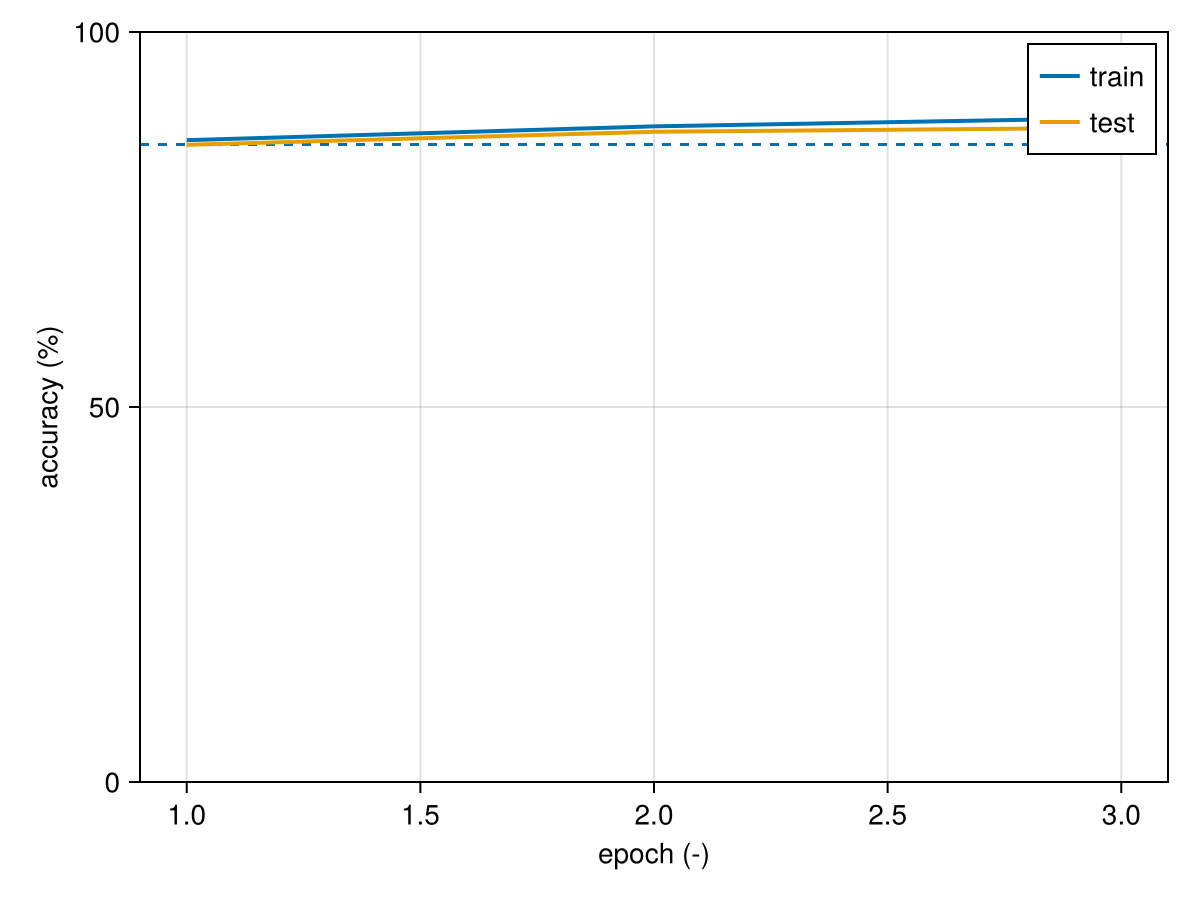

CairoMakie.Screen{IMAGE}


In [12]:
# Wykres accuracy

try
    using CairoMakie

    fig = Figure()
    ax = Axis(fig[1, 1], xlabel = "epoch (-)", ylabel = "accuracy (%)")
    hlines!(ax, [85], linestyle = :dash)
    lines!(ax, 1:settings.epochs, accuracy[:, 1], linewidth = 2, label = "train")
    lines!(ax, 1:settings.epochs, accuracy[:, 2], linewidth = 2, label = "test")
    ylims!(ax, (0, 100))
    axislegend(ax)
    display(fig)
catch e
    println("\nPominięto wykres, bo nie ma CairoMakie.")
    println("Komunikat: ", e)
end


In [13]:
# Jedna próbka testowa po treningu

x_test_1 = test_X[:, :, :, 1:1]
y_test_1 = test_y[:, 1:1]

x_test_var = Variable(x_test_1, name=:x_test_1)
y_test_hat = model(x_test_var)

order_single = topo_sort(y_test_hat)
forward!(order_single)

println("\nSingle test example: pred vs true")
println(hcat(argmax_classes(value(y_test_hat)), argmax_classes(y_test_1)))


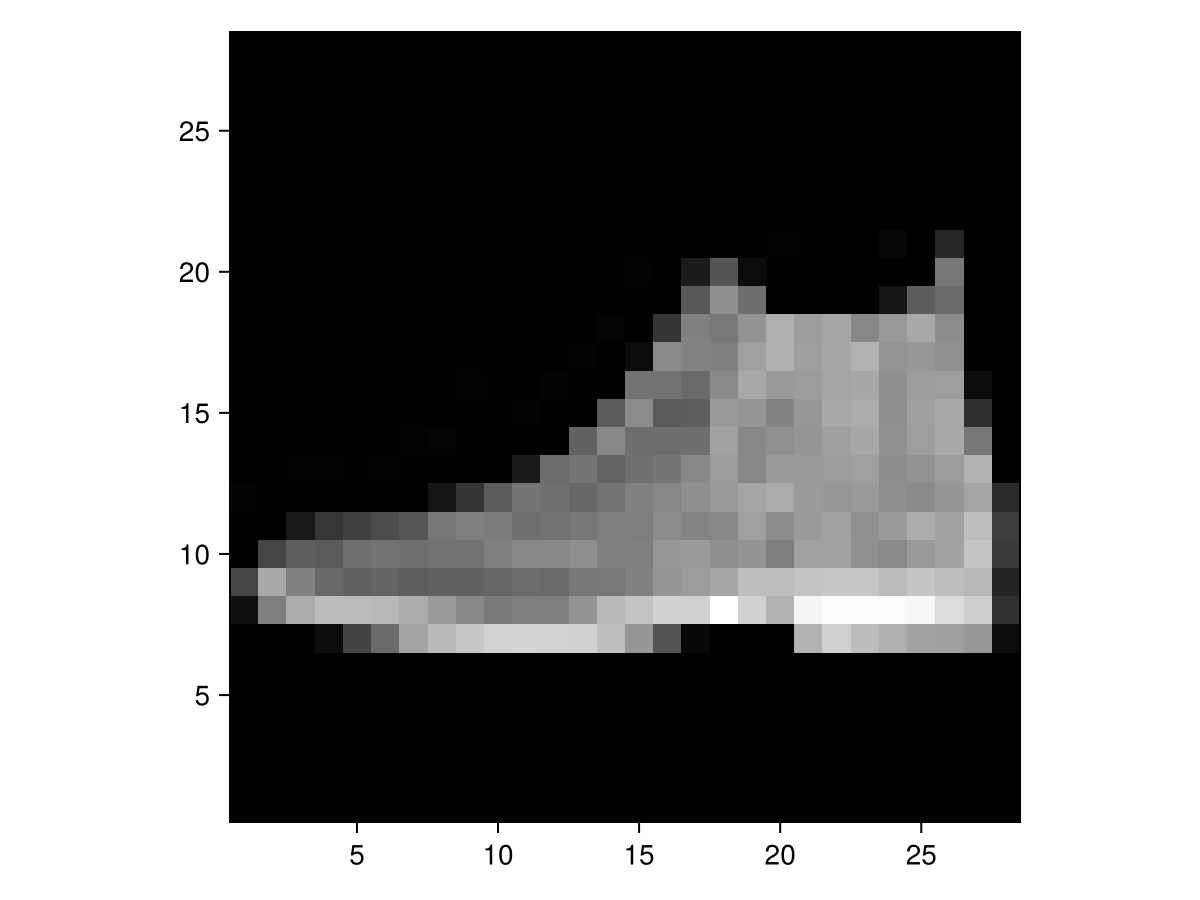

In [29]:
# Obrazek jednej próbki

try
    using CairoMakie

    img = test_X[:, :, 1, 1]
    img_rot = reverse(permutedims(img), dims=2)  # obrót o 90° w prawo

    heatmap(img_rot; colormap = :bone, axis = (aspect = DataAspect(), yreversed = false))

catch e
    println("Pominięto heatmapę, bo CairoMakie nie jest dostępne.")
    println("Komunikat: ", e)
end